In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler,OneHotEncoder

In [2]:
df = pd.read_csv("/content/student_performance_dataset.csv")

In [3]:
df.head()

,student_id,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score,final_grade
0,1,Male,4.0,98.0,6.5,Bachelors,Yes,Yes,No,76.9,100.0,A
1,2,Female,6.3,100.0,5.7,High School,Yes,Yes,Yes,75.5,100.0,A
2,3,Male,4.9,85.3,7.9,Bachelors,Yes,No,Yes,88.5,97.3,A
3,4,Male,2.6,77.5,8.0,NaN,Yes,Yes,No,85.1,83.8,B
4,5,Male,2.2,89.6,4.6,Bachelors,Yes,No,Yes,61.8,68.3,D


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   student_id                  1000 non-null   int64  
 1   gender                      1000 non-null   object 
 2   study_time_hours            1000 non-null   float64
 3   attendance_percent          1000 non-null   float64
 4   sleep_hours                 1000 non-null   float64
 5   parental_education          898 non-null    object 
 6   internet_access             1000 non-null   object 
 7   extracurricular_activities  1000 non-null   object 
 8   part_time_job               1000 non-null   object 
 9   previous_grade              1000 non-null   float64
 10  final_exam_score            1000 non-null   float64
 11  final_grade                 1000 non-null   object 
dtypes: float64(5), int64(1), object(6)
memory usage: 93.9+ KB


In [5]:
df.isnull().sum()

,0
student_id,0
gender,0
study_time_hours,0
attendance_percent,0
sleep_hours,0
parental_education,102
internet_access,0
extracurricular_activities,0
part_time_job,0
previous_grade,0


In [6]:
df = df.drop('student_id',axis=1)

In [7]:
cols = ['internet_access','extracurricular_activities','part_time_job']
for col in cols:
  df[col] = df[col].map({'Yes':1,'No':0})

In [8]:
df.head(2)

,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score,final_grade
0,Male,4.0,98.0,6.5,Bachelors,1,1,0,76.9,100.0,A
1,Female,6.3,100.0,5.7,High School,1,1,1,75.5,100.0,A


In [9]:
df['final_grade'].unique()

array(['A', 'B', 'D', 'C', 'F'], dtype=object)

<Axes: xlabel='sleep_hours', ylabel='count'>

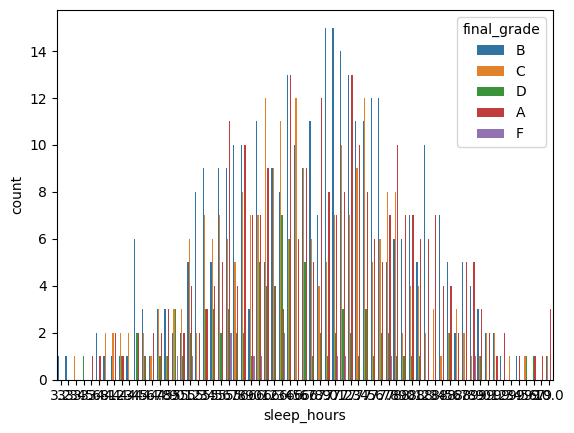

In [10]:
sns.countplot(x='sleep_hours',data=df,hue='final_grade')

<Axes: xlabel='sleep_hours', ylabel='attendance_percent'>

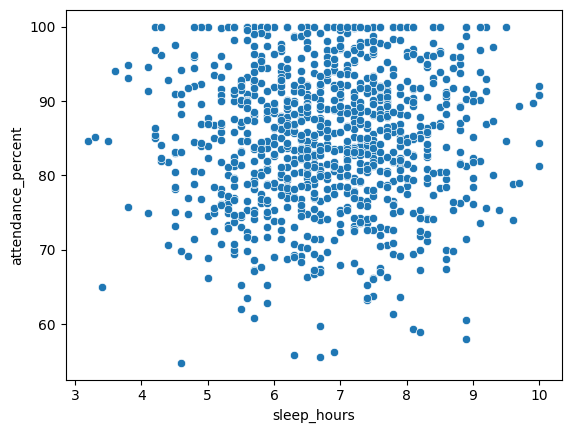

In [13]:
sns.scatterplot(x='sleep_hours',y='attendance_percent',data=df)

<Axes: xlabel='extracurricular_activities', ylabel='count'>

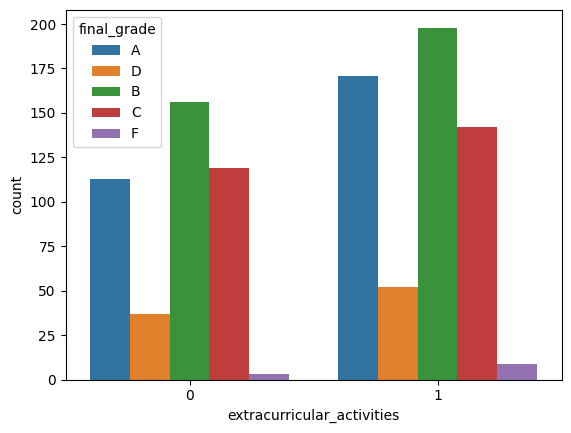

In [15]:
sns.countplot(x='extracurricular_activities',hue='final_grade',data=df)

In [18]:
df['final_exam_score'].unique()

array([100. ,  97.3,  83.8,  68.3,  81.6,  69.6,  88. ,  84.4,  74.3,
        68.9,  76.7,  82.6,  93.3,  73.9,  84.8,  81.5,  75.5,  89.7,
        92.8,  73.5,  73.4,  71.2,  97.2,  76. ,  78.7,  97.4,  84.2,
        89.8,  82.4,  87.7,  92.9,  83.2,  81.1,  89.5,  91.6,  75.3,
        79. ,  79.2,  70.8,  61.8,  68. ,  80.3,  88.6,  69.4,  81.8,
        72.6,  85.3,  99.8,  84.3,  71.5,  74.5,  80.4,  71.1,  87.8,
        73. ,  80.8,  67.8,  85.1,  79.6,  77.4,  94.6,  77.6,  99.9,
        64.4,  71.9,  79.3,  74.9,  87.4,  97.6,  64.1,  90. ,  99.3,
        63.9,  78.9,  84.5,  71.7,  86.3,  98.3,  88.1,  99.6,  74.8,
        88.5,  65.2,  66.3,  92.7,  87.2,  92.5,  75.7,  74. ,  61.7,
        91.4,  72.7,  74.6,  96.5,  94.5,  59.3,  96.2,  73.3,  95.8,
        81. ,  76.5,  92.1,  85.2,  63. ,  87.1,  77.3,  85.6,  59.7,
        80.9,  80.2,  75.9,  86.8,  82. ,  46.8,  68.6,  69.2,  84.7,
        95.4,  87.6,  89.3,  63.7,  87.9,  76.6,  90.2,  88.7,  82.1,
        75.1,  78.1,

In [36]:
X = df.drop('final_grade',axis=1)
y = df['final_grade']

In [33]:
from sklearn.preprocessing import LabelEncoder

In [37]:
le = LabelEncoder()
y = le.fit_transform(y)
print("Unique values of y after Label Encoding:", np.unique(y))

Unique values of y after Label Encoding: [0 1 2 3 4]


In [20]:
num_x = X.select_dtypes(include=np.number)
cat_x = X.select_dtypes(include='object')

In [21]:
from sklearn.impute import SimpleImputer

In [22]:
num_enc = Pipeline(steps=[
    ('impute',SimpleImputer(strategy='median')),
    ('scale',StandardScaler())
])
cat_enc = Pipeline(steps=[
    ('impute',SimpleImputer(strategy='most_frequent')),
    ('encode',OneHotEncoder())
])

In [23]:
from sklearn.compose import ColumnTransformer

In [24]:
preprocessor = ColumnTransformer(transformers=[
    ('num',num_enc,num_x.columns),
    ('cat',cat_enc,cat_x.columns)
])

In [29]:
from sklearn.linear_model import LogisticRegression

In [44]:
model = Pipeline(steps=[
    ('processing',preprocessor),
    ('model',LogisticRegression(class_weight='balanced'))
])

In [45]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [46]:
model.fit(X_train,y_train)

Pipeline(steps=[('processing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scale',
                                                                   StandardScaler())]),
                                                  Index(['study_time_hours', 'attendance_percent', 'sleep_hours',
       'internet_access', 'extracurricular_activities', 'part_time_job',
       'previous_grade', 'final_exam_score'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encode',
                                                                   OneHotEncoder())]),
                                                  Index(['gender', 'parental_education'], dtype='object'))])),
                ('model', LogisticRegression(class_weight='balanced'))])

In [47]:
y_pred = model.predict(X_test)

In [48]:
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix

accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f}")

Model Accuracy: 0.9000


In [49]:
classification_report = classification_report(y_test,y_pred)
print(f"Classification Report:\n{classification_report}")

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.98      0.97        47
           1       0.96      0.90      0.93        73
           2       0.87      0.87      0.87        55
           3       0.74      0.87      0.80        23
           4       0.00      0.00      0.00         2

    accuracy                           0.90       200
   macro avg       0.71      0.73      0.71       200
weighted avg       0.90      0.90      0.90       200



In [50]:
confusion_matrix = confusion_matrix(y_test,y_pred)
print(f"Confusion Matrix:\n{confusion_matrix}")

Confusion Matrix:
[[46  1  0  0  0]
 [ 2 66  5  0  0]
 [ 0  2 48  5  0]
 [ 0  0  2 20  1]
 [ 0  0  0  2  0]]


In [54]:
from sklearn.model_selection import cross_val_score

In [55]:
cv = cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring='accuracy'
)
print(f"Cross-Validation Scores: {cv}")
print(f"Mean Accuracy: {cv.mean():.4f}")

Cross-Validation Scores: [0.955 0.885 0.89  0.915 0.905]
Mean Accuracy: 0.9100


In [53]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier


In [57]:
algorithms = {
    'Random Forest': RandomForestClassifier(class_weight='balanced'),
    'Gradient Boosting': GradientBoostingClassifier(),
    'Support Vector Machine': SVC(C=0.1,gamma=10,class_weight='balanced'),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Naive Bayes': GaussianNB(),
    'XGBoost': XGBClassifier()
}

for name,algo in algorithms.items():
  # Create a pipeline for each algorithm that includes preprocessing
  model_pipeline = Pipeline(steps=[
      ('processing', preprocessor),
      ('model', algo)
  ])
  model_pipeline.fit(X_train,y_train)
  y_pred = model_pipeline.predict(X_test)
  accuracy = accuracy_score(y_test,y_pred)
  print(f"{name} Accuracy: {accuracy:.4f}")

Random Forest Accuracy: 0.9750
Gradient Boosting Accuracy: 0.9950
Support Vector Machine Accuracy: 0.3650
K-Nearest Neighbors Accuracy: 0.6450
Naive Bayes Accuracy: 0.9100
XGBoost Accuracy: 1.0000
